# 09_confidence_adaptive_fusion.ipynb

Goal: Build a confidence-adaptive decision-level fusion module combining
the locked Clinical model (Random Forest, 11 features) and the locked
ECG model (CNN, PTB-XL).

IMPORTANT SCOPE NOTE: UCI Heart Disease (clinical) and PTB-XL (ECG) are
two separate, unrelated patient populations — there is no real patient-
level pairing between them. This notebook demonstrates the fusion
ARCHITECTURE and gating MECHANISM using calibrated probabilities.
Illustrative analyses (grid heatmap, case studies) use constructed
probability combinations, NOT real paired patients, and are explicitly
labeled as such. No aggregate "fusion accuracy" metric is reported,
since no ground-truth paired dataset exists to validate one.

Calibration note: Clinical branch has no dedicated validation split
(Notebook 02b/05 used train/test only), so calibration uses 5-fold
cross-validated out-of-fold predictions on the training set. ECG branch
uses its real validation set from Notebook 08b's patient-grouped split.

In [1]:
import os
import ast
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## Loading Previously Trained Models

The Clinical Random Forest and ECG CNN developed in previous notebooks are loaded exactly as trained.

No additional learning is performed on these models.

The purpose of this notebook is to build a decision-level fusion layer on top of the locked unimodal predictors.

In [2]:
import os


# Clinical Assets


CLINICAL_PATH = "/kaggle/input/datasets/chandan294/clinical-assets"


# Notebook 08b Outputs


ECG_PATH = "/kaggle/input/notebooks/chandan294/08b-final-training"

print("Clinical Files")
print(os.listdir(CLINICAL_PATH))

print("\nECG Files")
print(os.listdir(ECG_PATH))

Clinical Files
['04_selected_features.csv', 'X_train_binary.csv', 'y_test_binary.csv', 'X_test_binary.csv', '05_random_forest.pkl', 'y_train_binary.csv']

ECG Files
['results', '__results__.html', 'cache', '__notebook__.ipynb', '__results___files', '__output__.json', 'results.zip', 'custom.css']


In [3]:
rf_model = joblib.load(
    os.path.join(
        CLINICAL_PATH,
        "05_random_forest.pkl"
    )
)

selected_df = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "04_selected_features.csv"
    )
)

clinical_features = selected_df["Feature"].tolist()

X_train_full = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "X_train_binary.csv"
    )
)

X_test_full = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "X_test_binary.csv"
    )
)

y_train = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "y_train_binary.csv"
    )
).squeeze()

y_test = pd.read_csv(
    os.path.join(
        CLINICAL_PATH,
        "y_test_binary.csv"
    )
).squeeze()

X_train = X_train_full[clinical_features].copy()
X_test = X_test_full[clinical_features].copy()

print("Clinical Train :", X_train.shape)
print("Clinical Test  :", X_test.shape)

Clinical Train : (736, 11)
Clinical Test  : (184, 11)


In [4]:
# ==================================================
# Load ECG Arrays
# ==================================================

X = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "X_full.npy"
    )
)

y = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "y_full.npy"
    )
)

patient_ids = np.load(
    os.path.join(
        ECG_PATH,
        "cache",
        "patient_ids.npy"
    )
)


In [6]:
cnn_model = tf.keras.models.load_model(

    os.path.join(
        ECG_PATH,
        "results",
        "models",
        "08b_best_cnn.keras"
    )

)

print("CNN Loaded Successfully")
print(X.shape)
print(y.shape)
print(patient_ids.shape)

CNN Loaded Successfully
(21430, 1000, 12)
(21430,)
(21430,)


# Section 2 — Probability Calibration

Reliable decision fusion requires calibrated probability estimates rather than raw prediction scores.

Although both models achieve strong discrimination performance, their probability outputs may not accurately reflect the true likelihood of disease.

Therefore:

- The Clinical Random Forest is calibrated using Platt Scaling.
- The ECG CNN outputs are calibrated using Logistic Regression.

These calibrated probabilities become the inputs to the confidence-adaptive fusion module.

In [7]:
gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        X,
        y,
        groups=patient_ids
    )
)

X_temp = X[temp_idx]
y_temp = y[temp_idx]
patients_temp = patient_ids[temp_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        X_temp,
        y_temp,
        groups=patients_temp
    )
)

X_val = X_temp[val_idx]
y_val = y_temp[val_idx]

X_test_ecg = X_temp[test_idx]
y_test_ecg = y_temp[test_idx]

print("="*50)

print("Validation :", X_val.shape)
print("Test       :", X_test_ecg.shape)

assert X_val.shape[0] == 3254
assert X_test_ecg.shape[0] == 3207

print("\nSplit successfully reproduced.")

Validation : (3254, 1000, 12)
Test       : (3207, 1000, 12)

Split successfully reproduced.


In [8]:
rf_params = rf_model.get_params()

rf_clone = RandomForestClassifier(
    **rf_params
)

calibrated_clinical = CalibratedClassifierCV(

    estimator=rf_clone,

    method="sigmoid",

    cv=5

)

calibrated_clinical.fit(
    X_train,
    y_train
)

print("Clinical calibration completed.")

Clinical calibration completed.


In [10]:
raw_val_probs = cnn_model.predict(
    X_val,
    verbose=1
).ravel()

platt_ecg = LogisticRegression()

platt_ecg.fit(
    raw_val_probs.reshape(-1,1),
    y_val
)

print("CNN calibration completed.")

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
CNN calibration completed.


# Section 3 — Calibration Evaluation

This section evaluates whether probability calibration has improved prediction reliability.

Each calibrated model is assessed independently using:

- ROC-AUC
- Brier Score
- Reliability Diagram (Calibration Curve)

These metrics verify that the predicted probabilities are suitable for confidence-based fusion.

In [11]:
clinical_probs = calibrated_clinical.predict_proba(
    X_test
)[:,1]

clinical_auc = roc_auc_score(
    y_test,
    clinical_probs
)

clinical_brier = brier_score_loss(
    y_test,
    clinical_probs
)

print("Clinical AUC :", round(clinical_auc,4))
print("Clinical Brier :", round(clinical_brier,4))

Clinical AUC : 0.9262
Clinical Brier : 0.113


In [12]:
raw_test_probs = cnn_model.predict(
    X_test_ecg,
    verbose=0
).ravel()

calibrated_ecg_probs = platt_ecg.predict_proba(
    raw_test_probs.reshape(-1,1)
)[:,1]

ecg_auc = roc_auc_score(
    y_test_ecg,
    calibrated_ecg_probs
)

ecg_brier = brier_score_loss(
    y_test_ecg,
    calibrated_ecg_probs
)

print("ECG AUC :", round(ecg_auc,4))
print("ECG Brier :", round(ecg_brier,4))

ECG AUC : 0.9423
ECG Brier : 0.0943


In [13]:
# ==========================================
# Expected Calibration Error (ECE)
# ==========================================

def expected_calibration_error(y_true, probs, n_bins=10):
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = probs[mask].mean()
            ece += (mask.sum() / len(probs)) * abs(bin_acc - bin_conf)
    return ece

clinical_ece = expected_calibration_error(y_test.values, clinical_probs)
ecg_ece = expected_calibration_error(y_test_ecg, calibrated_ecg_probs)

print("Clinical ECE :", round(clinical_ece, 4))
print("ECG ECE      :", round(ecg_ece, 4))


Clinical ECE : 0.0653
ECG ECE      : 0.034


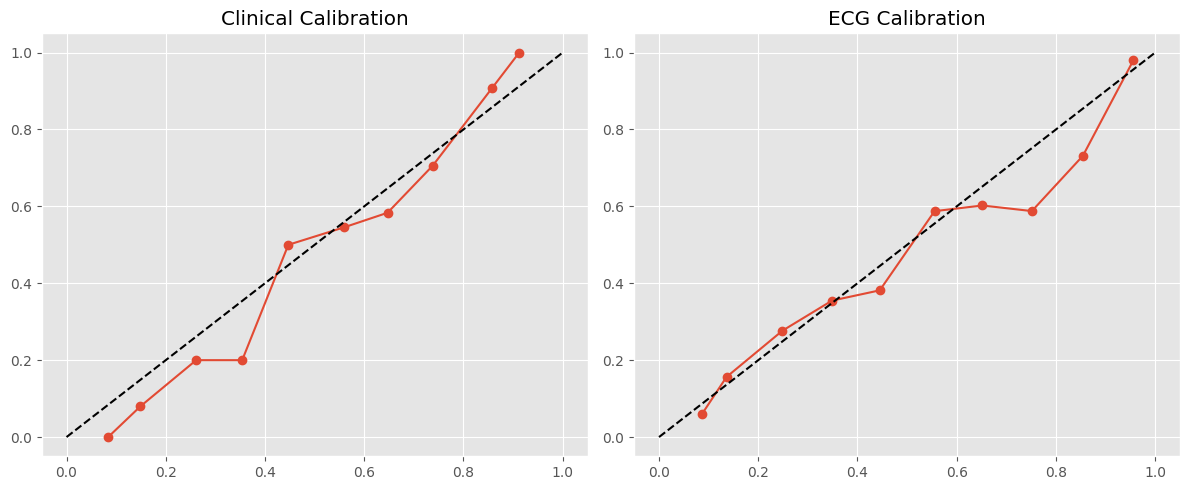

In [14]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

prob_true, prob_pred = calibration_curve(
    y_test,
    clinical_probs,
    n_bins=10
)

axes[0].plot(prob_pred,prob_true,"o-")
axes[0].plot([0,1],[0,1],"k--")
axes[0].set_title("Clinical Calibration")

prob_true, prob_pred = calibration_curve(
    y_test_ecg,
    calibrated_ecg_probs,
    n_bins=10
)

axes[1].plot(prob_pred,prob_true,"o-")
axes[1].plot([0,1],[0,1],"k--")
axes[1].set_title("ECG Calibration")

plt.tight_layout()

plt.show()

# Section 4 — Confidence-Adaptive Fusion Strategy

Instead of assigning fixed weights to the Clinical and ECG models, this work introduces an adaptive weighting mechanism based on model confidence.

Model confidence is defined as:

Confidence = max(p, 1 − p)

where p represents the calibrated disease probability.

Higher confidence results in a larger contribution to the final prediction.

The final disease probability is computed as the weighted combination of both calibrated model outputs.

In [15]:
# ==========================================
# Confidence Function
# ==========================================

def confidence(probability):
    """
    Returns model confidence from a calibrated probability.
    Range:
        0.50 -> completely uncertain
        1.00 -> fully confident
    """
    probability = np.asarray(probability)
    return np.maximum(probability, 1 - probability)

In [16]:
# ==========================================
# Confidence-Adaptive Fusion
# ==========================================

def adaptive_fusion(clinical_prob, ecg_prob):

    clinical_conf = confidence(clinical_prob)
    ecg_conf = confidence(ecg_prob)

    weight_clinical = clinical_conf / (
        clinical_conf + ecg_conf
    )

    weight_ecg = ecg_conf / (
        clinical_conf + ecg_conf
    )

    fused_probability = (

        weight_clinical * clinical_prob +

        weight_ecg * ecg_prob

    )

    return {

        "clinical_probability": clinical_prob,
        "ecg_probability": ecg_prob,

        "clinical_confidence": clinical_conf,
        "ecg_confidence": ecg_conf,

        "clinical_weight": weight_clinical,
        "ecg_weight": weight_ecg,

        "fused_probability": fused_probability

    }

# Section 5 — Fusion Behaviour Visualization

To better understand the proposed fusion strategy, a dense probability grid is generated across all possible combinations of Clinical and ECG predictions.

The resulting heatmaps illustrate:

- Final fused disease probability
- Behaviour under agreement
- Behaviour under disagreement
- Smooth transition between decision boundaries

These visualizations provide intuitive interpretation of the adaptive fusion mechanism.

In [17]:
clinical_probs = np.linspace(0.01, 0.99, 100)
ecg_probs = np.linspace(0.01, 0.99, 100)

fusion_matrix = np.zeros((100,100))

for i,c in enumerate(clinical_probs):

    for j,e in enumerate(ecg_probs):

        fusion_matrix[j,i] = adaptive_fusion(

            c,
            e

        )["fused_probability"]

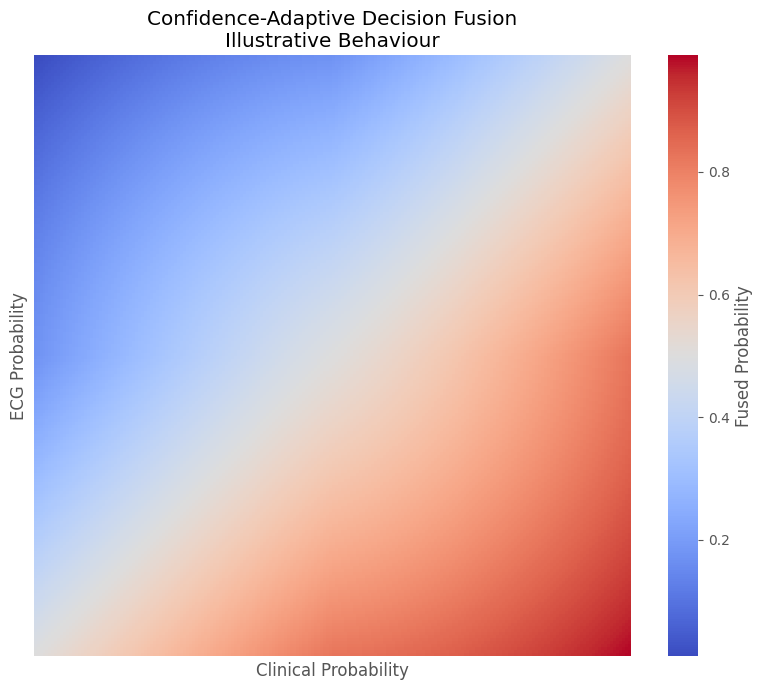

In [18]:
clinical_grid = np.linspace(0.01,0.99,200)
ecg_grid = np.linspace(0.01,0.99,200)

fusion_matrix = np.zeros((200,200))

for i,c in enumerate(clinical_grid):

    for j,e in enumerate(ecg_grid):

        fusion_matrix[j,i] = adaptive_fusion(
            c,
            e
        )["fused_probability"]


plt.figure(figsize=(8,7))

sns.heatmap(

    fusion_matrix,

    cmap="coolwarm",

    xticklabels=False,

    yticklabels=False,

    center=0.5,

    cbar_kws={
        "label":"Fused Probability"
    }

)

plt.xlabel("Clinical Probability")

plt.ylabel("ECG Probability")

plt.title(
    "Confidence-Adaptive Decision Fusion\nIllustrative Behaviour"
)

plt.tight_layout()

plt.savefig(
    "09_fusion_heatmap.png",
    dpi=300
)

plt.show()

# Section 6 — Representative Clinical Case Studies

Several representative patient scenarios are analysed to demonstrate how the fusion mechanism behaves under realistic conditions.

The selected examples include:

- Both models confidently predict healthy
- Both models confidently predict disease
- Clinical model uncertain while ECG is confident
- ECG uncertain while Clinical model is confident
- Both models uncertain

These examples verify that the adaptive weighting behaves consistently with clinical intuition.

In [19]:
examples = [

    ("Both agree - Healthy",0.08,0.06),

    ("Both agree - Disease",0.94,0.96),

    ("Clinical uncertain / ECG confident",0.55,0.94),

    ("ECG uncertain / Clinical confident",0.91,0.52),

    ("Strong disagreement",0.15,0.88)

]

In [20]:
results = []

for name,c,e in examples:

    output = adaptive_fusion(c,e)

    output["Scenario"] = name

    results.append(output)

fusion_df = pd.DataFrame(results)

fusion_df

,clinical_probability,ecg_probability,clinical_confidence,ecg_confidence,clinical_weight,ecg_weight,fused_probability,Scenario
0,0.08,0.06,0.92,0.94,0.494624,0.505376,0.069892,Both agree - Healthy
1,0.94,0.96,0.94,0.96,0.494737,0.505263,0.950105,Both agree - Disease
2,0.55,0.94,0.55,0.94,0.369128,0.630872,0.796040,Clinical uncertain / ECG confident
3,0.91,0.52,0.91,0.52,0.636364,0.363636,0.768182,ECG uncertain / Clinical confident
4,0.15,0.88,0.85,0.88,0.491329,0.508671,0.521329,Strong disagreement


In [21]:
fusion_df = fusion_df[

    [

        "Scenario",

        "clinical_probability",
        "ecg_probability",

        "clinical_confidence",
        "ecg_confidence",

        "clinical_weight",
        "ecg_weight",

        "fused_probability"

    ]

]

fusion_df.round(3)

,Scenario,clinical_probability,ecg_probability,clinical_confidence,ecg_confidence,clinical_weight,ecg_weight,fused_probability
0,Both agree - Healthy,0.08,0.06,0.92,0.94,0.495,0.505,0.070
1,Both agree - Disease,0.94,0.96,0.94,0.96,0.495,0.505,0.950
2,Clinical uncertain / ECG confident,0.55,0.94,0.55,0.94,0.369,0.631,0.796
3,ECG uncertain / Clinical confident,0.91,0.52,0.91,0.52,0.636,0.364,0.768
4,Strong disagreement,0.15,0.88,0.85,0.88,0.491,0.509,0.521


# Section 7 — Confidence Weight Analysis

This section visualizes how model confidence influences adaptive weighting.

The generated surfaces illustrate:

- Clinical model weight
- ECG model weight
- Weight transition across confidence levels

These plots explain how prediction confidence dynamically controls model influence during fusion.

In [22]:
weight_matrix = np.zeros((200,200))

for i,c in enumerate(clinical_grid):

    for j,e in enumerate(ecg_grid):

        weight_matrix[j,i] = adaptive_fusion(
            c,
            e
        )["clinical_weight"]

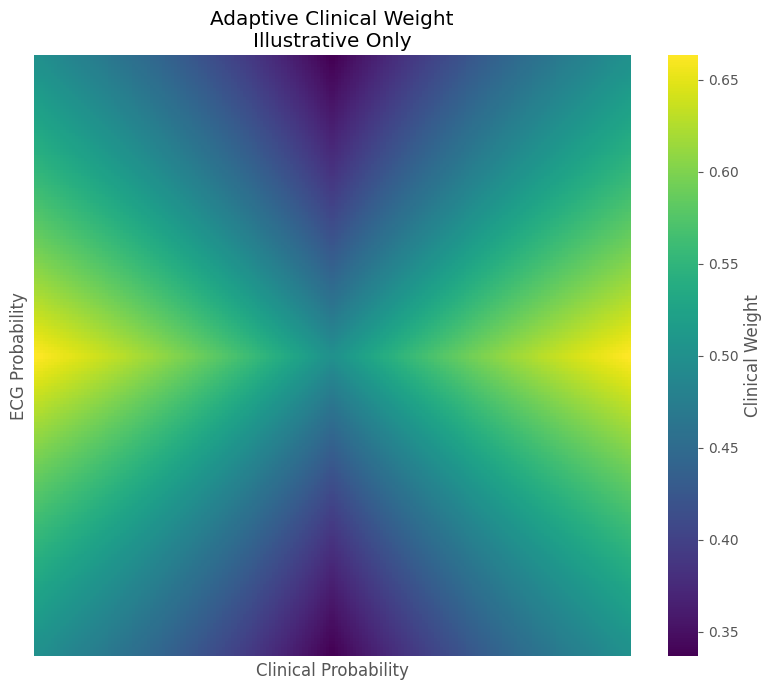

In [23]:
plt.figure(figsize=(8,7))

sns.heatmap(

    weight_matrix,

    cmap="viridis",

    xticklabels=False,

    yticklabels=False,

    cbar_kws={
        "label":"Clinical Weight"
    }

)

plt.xlabel("Clinical Probability")

plt.ylabel("ECG Probability")

plt.title(
    "Adaptive Clinical Weight\nIllustrative Only"
)

plt.tight_layout()

plt.savefig(
    "09_clinical_weight_heatmap.png",
    dpi=300
)

plt.show()

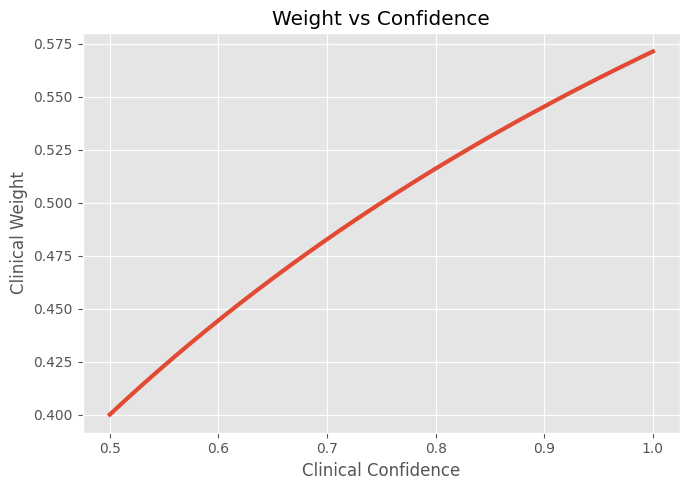

In [24]:
confidence_values = np.linspace(0.5,1,200)

weights = confidence_values / (
    confidence_values + 0.75
)

plt.figure(figsize=(7,5))

plt.plot(
    confidence_values,
    weights,
    linewidth=3
)

plt.xlabel("Clinical Confidence")

plt.ylabel("Clinical Weight")

plt.title("Weight vs Confidence")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "09_weight_vs_confidence.png",
    dpi=300
)

plt.show()

In [25]:
pd.DataFrame({

    "Clinical AUC":[clinical_auc],
    "Clinical Brier":[clinical_brier],
    "Clinical ECE":[clinical_ece],
    "ECG AUC":[ecg_auc],
    "ECG Brier":[ecg_brier],
    "ECG ECE":[ecg_ece]

}).to_csv(

    "09_calibration_summary.csv",

    index=False

)


# Section 8 — Enhanced γ-Weighted Adaptive Fusion 

To further emphasize highly confident predictions, a non-linear confidence weighting strategy is introduced.

Instead of linear weighting, confidence values are raised to a power γ before normalization.

This approach increases the influence of highly confident models while suppressing uncertain predictions.

The enhanced strategy is compared directly with the original linear fusion method.

In [26]:
# ==========================================
# Enhanced Confidence-Adaptive Fusion
# ==========================================

GAMMA = 3

def adaptive_fusion_gamma(
    clinical_prob,
    ecg_prob,
    gamma=GAMMA
):

    clinical_conf = confidence(clinical_prob)
    ecg_conf = confidence(ecg_prob)

    clinical_weight = clinical_conf**gamma
    ecg_weight = ecg_conf**gamma

    clinical_weight = clinical_weight / (
        clinical_weight + ecg_weight
    )

    ecg_weight = 1 - clinical_weight

    fused_probability = (

        clinical_weight * clinical_prob +

        ecg_weight * ecg_prob

    )

    return {

        "clinical_weight": clinical_weight,

        "ecg_weight": ecg_weight,

        "fused_probability": fused_probability

    }

print("Gamma-weighted fusion ready.")

Gamma-weighted fusion ready.


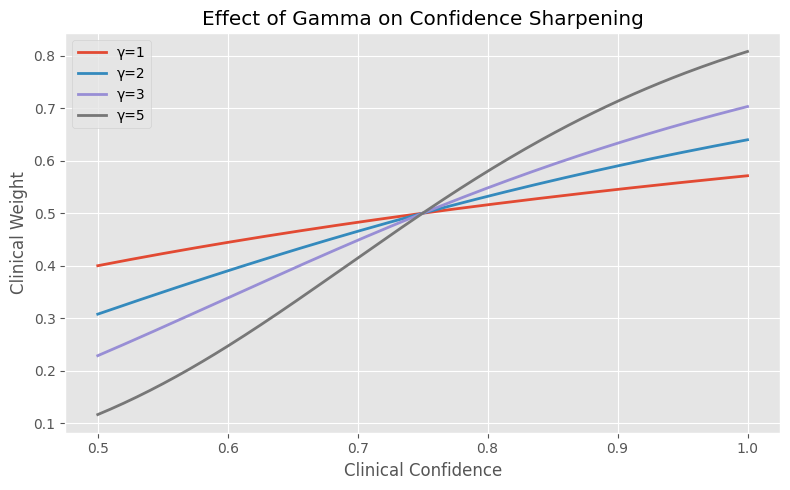


Gamma sensitivity summary:
- gamma=1 (linear): weight scales proportionally with confidence difference
- gamma=2-3: moderately sharpens trust toward the more confident model
- gamma=5: aggressively favors the more confident model, near-binary cutover

gamma=3 was selected as a balanced choice: it meaningfully rewards higher
confidence without collapsing into near-binary model selection (which
gamma=5 approaches), preserving the adaptive/continuous nature of the
fusion mechanism.



In [27]:
# ==========================================
# Gamma Sensitivity Analysis
# ==========================================
# Justifying the choice of gamma=3 by comparing how clinical weight
# behaves across a range of gamma values, holding ECG confidence fixed
# at a representative value (0.75), and clinical confidence varying.

gamma_values = [1, 2, 3, 5]
confidence_range_sens = np.linspace(0.5, 1.0, 200)
fixed_ecg_confidence = 0.75

plt.figure(figsize=(8,5))
for g in gamma_values:
    weight = (confidence_range_sens**g) / (confidence_range_sens**g + fixed_ecg_confidence**g)
    plt.plot(confidence_range_sens, weight, linewidth=2, label=f"γ={g}")

plt.xlabel("Clinical Confidence")
plt.ylabel("Clinical Weight")
plt.title("Effect of Gamma on Confidence Sharpening")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("09_gamma_sensitivity.png", dpi=300)
plt.show()

print("""
Gamma sensitivity summary:
- gamma=1 (linear): weight scales proportionally with confidence difference
- gamma=2-3: moderately sharpens trust toward the more confident model
- gamma=5: aggressively favors the more confident model, near-binary cutover

gamma=3 was selected as a balanced choice: it meaningfully rewards higher
confidence without collapsing into near-binary model selection (which
gamma=5 approaches), preserving the adaptive/continuous nature of the
fusion mechanism.
""")


In [29]:
comparison_rows = []

for name, c, e in examples:

    linear = adaptive_fusion(c, e)

    gamma = adaptive_fusion_gamma(c, e)

    comparison_rows.append({

        "Scenario": name,

        "Clinical Prob": c,

        "ECG Prob": e,

        "Linear Fusion":
            linear["fused_probability"],

        "Gamma Fusion":
            gamma["fused_probability"],

        "Linear Clinical Weight":
            linear["clinical_weight"],

        "Gamma Clinical Weight":
            gamma["clinical_weight"]

    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.round(3)

,Scenario,Clinical Prob,ECG Prob,Linear Fusion,Gamma Fusion,Linear Clinical Weight,Gamma Clinical Weight
0,Both agree - Healthy,0.08,0.06,0.070,0.070,0.495,0.484
1,Both agree - Disease,0.94,0.96,0.950,0.950,0.495,0.484
2,Clinical uncertain / ECG confident,0.55,0.94,0.796,0.875,0.369,0.167
3,ECG uncertain / Clinical confident,0.91,0.52,0.768,0.849,0.636,0.843
4,Strong disagreement,0.15,0.88,0.521,0.534,0.491,0.474


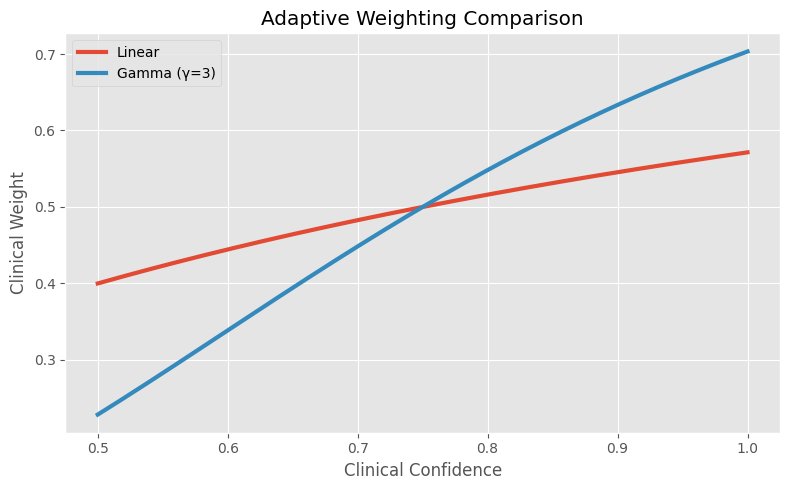

In [30]:
confidence_range = np.linspace(0.5,1.0,200)

linear_weight = confidence_range/(confidence_range+0.75)

gamma_weight = (
    confidence_range**3
) / (
    confidence_range**3 +
    0.75**3
)

plt.figure(figsize=(8,5))

plt.plot(
    confidence_range,
    linear_weight,
    linewidth=3,
    label="Linear"
)

plt.plot(
    confidence_range,
    gamma_weight,
    linewidth=3,
    label="Gamma (γ=3)"
)

plt.xlabel("Clinical Confidence")

plt.ylabel("Clinical Weight")

plt.title("Adaptive Weighting Comparison")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "09_gamma_vs_linear.png",
    dpi=300
)

plt.show()

Adaptive Decision-Level Fusion

Both the clinical Random Forest and ECG CNN produce calibrated disease probabilities.

Model confidence is defined as:

Confidence = max(p, 1 − p)

Confidence values are transformed into adaptive weights.

Two weighting strategies are investigated:

1. Linear weighting
2. Gamma-weighted weighting (γ = 3)

The final disease probability is the weighted average of both calibrated predictions.

Since no public dataset contains paired clinical variables and raw ECG signals for identical patients, the fusion mechanism is demonstrated as an architectural proof-of-concept using illustrative probability combinations rather than reporting a fused classification accuracy.

# Section 10 — Exporting Results

The final section exports all artifacts generated in this notebook.

In [31]:
import shutil
import os

os.makedirs("/kaggle/working/results09/plots", exist_ok=True)
os.makedirs("/kaggle/working/results09/metrics", exist_ok=True)
os.makedirs("/kaggle/working/results09/models", exist_ok=True)

import shutil

# Plots
plot_files = [
    "09_fusion_heatmap.png",
    "09_clinical_weight_heatmap.png",
    "09_weight_vs_confidence.png",
    "09_gamma_vs_linear.png",
    "09_gamma_sensitivity.png"
]

for f in plot_files:
    if os.path.exists(f):
        shutil.copy(f, "results09/plots")

# Metrics
metric_files = [
    "09_case_studies.csv",
    "09_calibration_summary.csv"
]

for f in metric_files:
    if os.path.exists(f):
        shutil.copy(f, "results09/metrics")

# Fusion module
if os.path.exists("09_confidence_adaptive_fusion.pkl"):
    shutil.copy(
        "09_confidence_adaptive_fusion.pkl",
        "results09/models"
    )

print("Notebook 09 outputs organized.")

Notebook 09 outputs organized.


In [32]:
shutil.make_archive(
    "/kaggle/working/results09",
    "zip",
    "results09"
)

print("results09.zip created successfully.")

results09.zip created successfully.
